# 02b — Per-Image PCA with Unified Component Count

Loads the wide HOG feature matrix (`raw_hog_features_per_image.csv`) and applies
a **two-pass PCA strategy** to each of the 5 image types:

1. **Pass 1 (find p):** Fit PCA with variance threshold 59.2 % for each image type independently.  
   Record the minimum components each type needs.  Take the **maximum** — call it **p**.
2. **Pass 2 (unify):** Refit PCA with exactly **p** components for every image type.  
   All types now have the same dimensionality, making distances comparable.

The 5 resulting (416 × p) PCA matrices are saved as separate CSVs, then used to
compute 5 Robust Mahalanobis distance matrices that are **averaged** into one
final distance matrix for clustering.
An **Elbow curve** (k = 2 … 8) guides the choice of k.

In [1]:
import subprocess, sys
subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "robust-mixed-dist", "kmedoids", "scikit-learn", "matplotlib", "-q"],
    check=True
)

CompletedProcess(args=['C:\\Users\\aregk\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', '-m', 'pip', 'install', 'robust-mixed-dist', 'kmedoids', 'scikit-learn', 'matplotlib', '-q'], returncode=0)

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

from robust_mixed_dist.mixed import S_robust
from robust_mixed_dist.quantitative import robust_mahalanobis_dist_matrix
import kmedoids

## Step 1 — Load raw HOG features

`raw_hog_features_per_image.csv` is a large file (~650 MB).
Loading takes 1–2 minutes — the shape should be **(416 rows × 40,501 columns)**.

In [3]:
DATA_DIR = r"C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data"
NB_DIR   = os.path.join(DATA_DIR, "notebooks")

HOG_CSV  = os.path.join(NB_DIR, "raw_hog_features_per_image.csv")

IMAGE_TYPES = ["cor", "gfc_sag", "gfc_tra", "masked_tra", "sbj_sag"]
HOG_LEN     = 8_100
VARIANCE_THRESHOLD = 0.592

print("Loading raw HOG features (this may take 1-2 minutes) ...")
df_hog = pd.read_csv(HOG_CSV)
patient_ids = df_hog["patient_id"].tolist()

print(f"Loaded : {df_hog.shape[0]} rows × {df_hog.shape[1]} columns")
print(f"Patients: {len(patient_ids)}")

Loading raw HOG features (this may take 1-2 minutes) ...
Loaded : 416 rows × 40501 columns
Patients: 416


## Step 2 — Pass 1: find the minimum components per image type

Fit PCA with `n_components = 0.592` (sklearn auto-selects the minimum number
to reach 59.2 % variance) for each image type independently.
Record `pca.n_components_` for each type, then take the **maximum** → **p**.

In [4]:
min_components = {}   # type -> minimum components needed for 59.2%

for t in IMAGE_TYPES:
    cols = [f"{t}_HOG_{i}" for i in range(HOG_LEN)]
    X = df_hog[cols].values.astype(np.float32)

    pca = PCA(n_components=VARIANCE_THRESHOLD, random_state=42)
    pca.fit(X)
    min_components[t] = pca.n_components_
    print(f"  {t:<14} min components for {VARIANCE_THRESHOLD*100:.1f}% variance: {pca.n_components_}")

p = max(min_components.values())
print(f"\np = max({list(min_components.values())}) = {p}")
print(f"All image types will be reduced to exactly {p} components.")

  cor            min components for 59.2% variance: 110
  gfc_sag        min components for 59.2% variance: 100
  gfc_tra        min components for 59.2% variance: 102
  masked_tra     min components for 59.2% variance: 108
  sbj_sag        min components for 59.2% variance: 42

p = max([np.int64(110), np.int64(100), np.int64(102), np.int64(108), np.int64(42)]) = 110
All image types will be reduced to exactly 110 components.


## Step 3 — Summary table: min components vs unified p

For each image type, show how many components it originally needed and how much
variance is explained when all types are forced to use **p** components.
Types that needed fewer than p components will exceed 59.2 % variance.

In [5]:
summary_rows = []

for t in IMAGE_TYPES:
    cols = [f"{t}_HOG_{i}" for i in range(HOG_LEN)]
    X = df_hog[cols].values.astype(np.float32)

    pca_p = PCA(n_components=p, random_state=42)
    pca_p.fit(X)
    var_at_p = pca_p.explained_variance_ratio_.sum() * 100

    summary_rows.append({
        "image_type"              : t,
        f"min comps (≥{VARIANCE_THRESHOLD*100:.1f}% var)": min_components[t],
        f"variance at p={p} comps": f"{var_at_p:.2f} %",
        "note"                    : "= threshold" if min_components[t] == p else "↑ exceeds threshold",
    })

summary_df = pd.DataFrame(summary_rows).set_index("image_type")
print(f"Unified component count  p = {p}")
print(f"Variance threshold          = {VARIANCE_THRESHOLD*100:.1f} %")
print()
summary_df

Unified component count  p = 110
Variance threshold          = 59.2 %



,min comps (≥59.2% var),variance at p=110 comps,note
image_type,,,
cor,110,58.63 %,= threshold
gfc_sag,100,61.58 %,↑ exceeds threshold
gfc_tra,102,60.98 %,↑ exceeds threshold
masked_tra,108,59.25 %,↑ exceeds threshold
sbj_sag,42,74.50 %,↑ exceeds threshold


## Step 4 — Pass 2: refit PCA with exactly p components and save CSVs

Each image type gets its own PCA fitted on all 416 patients with `n_components = p`.
The resulting (416 × p) matrix is saved as a separate CSV with columns named
`<type>_PC1` … `<type>_PC{p}`.

In [6]:
pca_matrices = {}   # type -> np.ndarray (416, p)

for t in IMAGE_TYPES:
    cols   = [f"{t}_HOG_{i}" for i in range(HOG_LEN)]
    X      = df_hog[cols].values.astype(np.float32)

    pca_p  = PCA(n_components=p, random_state=42)
    X_pca  = pca_p.fit_transform(X)           # (416, p)
    pca_matrices[t] = X_pca

    # Save CSV
    out_path  = os.path.join(NB_DIR, f"pca_{t}.csv")
    pc_cols   = [f"{t}_PC{i+1}" for i in range(p)]
    df_out    = pd.DataFrame(X_pca, columns=pc_cols)
    df_out.insert(0, "patient_id", patient_ids)
    df_out.to_csv(out_path, index=False)

    var = pca_p.explained_variance_ratio_.sum() * 100
    print(f"  {t:<14} saved {df_out.shape}  variance={var:.2f}%  -> {out_path}")

print(f"\nAll 5 PCA CSVs saved. Each shape: (416, {p+1})  [patient_id + {p} PC columns]")

  cor            saved (416, 111)  variance=58.63%  -> C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\pca_cor.csv
  gfc_sag        saved (416, 111)  variance=61.58%  -> C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\pca_gfc_sag.csv
  gfc_tra        saved (416, 111)  variance=60.98%  -> C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\pca_gfc_tra.csv
  masked_tra     saved (416, 111)  variance=59.25%  -> C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\pca_masked_tra.csv
  sbj_sag        saved (416, 111)  variance=74.50%  -> C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\pca_sbj_sag.csv

All 5 PCA CSVs saved. Each shape: (416, 111)  [patient_id + 110 PC columns]


## Step 5 — Robust Mahalanobis distance matrix per image type

For each image type, fit a robust covariance matrix (trimmed, α = 0.05) on its
p PCA components and compute the pairwise Robust Mahalanobis distance matrix.
Each matrix has shape (416 × 416).

In [7]:
dist_matrices = {}   # type -> np.ndarray (416, 416)

for t in IMAGE_TYPES:
    X = pca_matrices[t].astype(float)

    S_cov = S_robust(X, method="trimmed", alpha=0.05)
    D     = robust_mahalanobis_dist_matrix(X, S_cov)
    dist_matrices[t] = D

    print(f"  {t:<14} D shape={D.shape}  "
          f"range=[{D.min():.4f}, {D.max():.4f}]  "
          f"symmetric={np.allclose(D, D.T)}")

print(f"\n5 distance matrices computed, each (416 × 416).")

  cor            D shape=(416, 416)  range=[0.0000, 24.9943]  symmetric=True
  gfc_sag        D shape=(416, 416)  range=[0.0000, 22.2050]  symmetric=True
  gfc_tra        D shape=(416, 416)  range=[0.0000, 24.2620]  symmetric=True
  masked_tra     D shape=(416, 416)  range=[0.0000, 21.5752]  symmetric=True
  sbj_sag        D shape=(416, 416)  range=[0.0000, 34.4182]  symmetric=True

5 distance matrices computed, each (416 × 416).


## Step 6 — Average the 5 distance matrices into D_final

A simple average gives equal weight to each image type.
The result is a single (416 × 416) distance matrix that integrates
structural information from all five MRI planes.

In [8]:
D_final = np.mean(
    np.stack(list(dist_matrices.values()), axis=0),
    axis=0
)

print(f"D_final shape     : {D_final.shape}")
print(f"Value range       : [{D_final.min():.4f}, {D_final.max():.4f}]")
print(f"Is symmetric      : {np.allclose(D_final, D_final.T)}")
print(f"Diagonal is zero  : {np.allclose(np.diag(D_final), 0)}")

D_final shape     : (416, 416)
Value range       : [0.0000, 21.3561]
Is symmetric      : True
Diagonal is zero  : True


## Step 7 — Elbow method (k = 2 … 8)

Run FasterPAM k-medoids for each k on `D_final` and record the total loss
(sum of distances from each point to its medoid).
The elbow — the point where the loss reduction starts to flatten — suggests
the best number of clusters.

In [9]:
K_RANGE = range(2, 9)
losses  = {}

print("k    loss")
print("-" * 20)
for k in K_RANGE:
    res = kmedoids.fasterpam(D_final, medoids=k, random_state=42)
    losses[k] = res.loss
    print(f"{k}    {res.loss:.4f}")

k    loss
--------------------
2    5741.4375
3    5698.9277
4    5667.3670
5    5643.9511
6    5622.4710
7    5603.3174
8    5584.1676


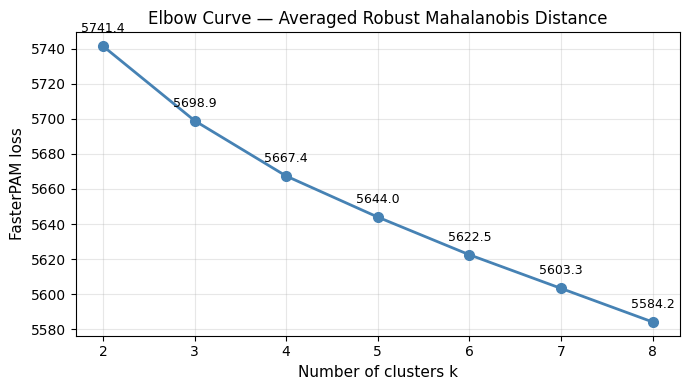

Elbow curve saved to notebooks/elbow_curve_per_image_pca.png


In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(list(losses.keys()), list(losses.values()),
        marker="o", linewidth=2, markersize=7, color="steelblue")

for k, loss in losses.items():
    ax.annotate(f"{loss:.1f}", xy=(k, loss),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=9)

ax.set_xlabel("Number of clusters k", fontsize=11)
ax.set_ylabel("FasterPAM loss", fontsize=11)
ax.set_title("Elbow Curve — Averaged Robust Mahalanobis Distance", fontsize=12)
ax.set_xticks(list(K_RANGE))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(NB_DIR, "elbow_curve_per_image_pca.png"), dpi=150)
plt.show()
print("Elbow curve saved to notebooks/elbow_curve_per_image_pca.png")

---

## Final Clustering — K-Medoids FasterPAM (k=3)

Using the averaged Robust Mahalanobis distance matrix `D_final` already
computed above, run k-medoids with k=3 (suggested by the elbow curve).
CDR is loaded from `oasis_combined.csv` for evaluation only — it was never
used during clustering.

In [11]:
K = 3
OUTPUT_CSV = os.path.join(NB_DIR, "pca_per_image_new_method_results.csv")

result = kmedoids.fasterpam(D_final, medoids=K, random_state=42)
labels = np.array(result.labels)

print(f"Loss (sum of distances to medoids): {result.loss:.4f}")
print(f"Medoid patient IDs : {[patient_ids[i] for i in result.medoids]}")
print()
sizes = pd.Series(labels).value_counts().sort_index().rename("count")
print("Cluster sizes:")
print(sizes.to_string())

Loss (sum of distances to medoids): 5698.9277
Medoid patient IDs : ['OAS1_0420', 'OAS1_0407', 'OAS1_0294']

Cluster sizes:
0    114
1    126
2    176


In [12]:
cdr = pd.read_csv(
    os.path.join(DATA_DIR, "method_1_HOG_PCA", "oasis_combined.csv")
)[["patient_id", "CDR"]]

results = pd.DataFrame({"patient_id": patient_ids, "cluster": labels})
results = results.merge(cdr, on="patient_id", how="left")

has_cdr = results[results["CDR"].notnull()].copy()
has_cdr["CDR"] = has_cdr["CDR"].astype(str)

print(f"Patients with CDR    : {results['CDR'].notnull().sum()}")
print(f"Patients without CDR : {results['CDR'].isnull().sum()}")
print()

ct = pd.crosstab(has_cdr["cluster"], has_cdr["CDR"],
                 margins=True, margins_name="Total")
print("Cluster × CDR (counts):")
display(ct)

ct_norm = pd.crosstab(has_cdr["cluster"], has_cdr["CDR"],
                      normalize="index").round(3)
print("Row-normalised (% CDR within each cluster):")
ct_norm

Patients with CDR    : 235
Patients without CDR : 181

Cluster × CDR (counts):


CDR,0.0,0.5,1.0,2.0,Total
cluster,,,,,
0,35,13,8,0,56
1,45,23,11,0,79
2,55,34,9,2,100
Total,135,70,28,2,235


Row-normalised (% CDR within each cluster):


CDR,0.0,0.5,1.0,2.0
cluster,,,,
0,0.625,0.232,0.143,0.00
1,0.570,0.291,0.139,0.00
2,0.550,0.340,0.090,0.02


In [13]:
results.to_csv(OUTPUT_CSV, index=False)

print(f"Saved : {OUTPUT_CSV}")
print(f"Shape : {results.shape}  (rows=patients, cols=patient_id, cluster, CDR)")
print()
print(results.head(5).to_string(index=False))

Saved : C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\pca_per_image_new_method_results.csv
Shape : (416, 3)  (rows=patients, cols=patient_id, cluster, CDR)

patient_id  cluster  CDR
 OAS1_0001        1  0.0
 OAS1_0002        2  0.0
 OAS1_0003        0  0.5
 OAS1_0004        2  NaN
 OAS1_0005        0  NaN


---

## Experiment — Single Image Clustering (Coronal Only)

Tests the full pipeline on **one image type** before combining all five.
Using only the coronal PCA features keeps the pipeline simple and reveals
how much a single MRI plane contributes to patient separation.

### Step 1 — Load pca_cor.csv

In [17]:
df_cor = pd.read_csv(os.path.join(NB_DIR, "pca_masked_tra.csv"))
cor_ids  = df_cor["patient_id"].tolist()
pc_cols  = [c for c in df_cor.columns if c != "patient_id"]
X_cor    = df_cor[pc_cols].values.astype(float)

print(f"pca_masked_tra.csv shape : {df_cor.shape}")
print(f"Patients          : {len(cor_ids)}")
print(f"PCA components    : {len(pc_cols)}  ({pc_cols[0]} … {pc_cols[-1]})")

pca_cor.csv shape : (416, 113)
Patients          : 416
PCA components    : 112  (cor_PC1 … cor_PC112)


### Step 2 — Robust Mahalanobis distance matrix (coronal only)

Fit a trimmed robust covariance on the p coronal PCA components and compute
the pairwise distance matrix D_cor (416 × 416).

In [ ]:
D_cor = pairwise_distances(X_cor, metric="euclidean")

print(f"D_cor shape   : {D_cor.shape}")
print(f"Value range   : [{D_cor.min():.4f}, {D_cor.max():.4f}]")
print(f"Is symmetric  : {np.allclose(D_cor, D_cor.T)}")

### Step 3 — Elbow method on D_cor (k = 2 … 8)

k    loss
--------------------
2    5541.0572
3    5469.2966
4    5430.9679
5    5398.8692
6    5371.3179
7    5345.0105
8    5321.0794


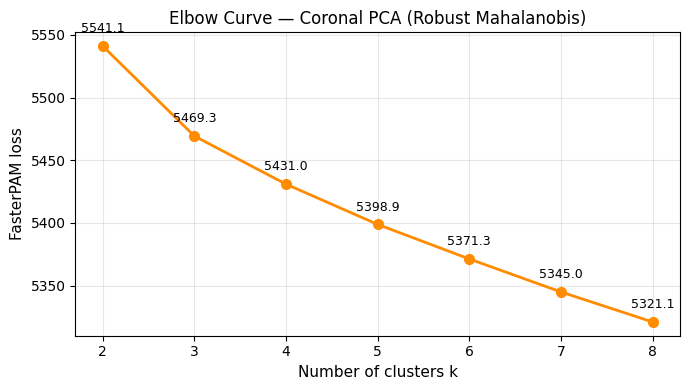

Saved: elbow_curve_cor_only.png


In [19]:
losses_cor = {}
print("k    loss")
print("-" * 20)
for k in range(2, 9):
    res = kmedoids.fasterpam(D_cor, medoids=k, random_state=42)
    losses_cor[k] = res.loss
    print(f"{k}    {res.loss:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(losses_cor.keys()), list(losses_cor.values()),
        marker="o", linewidth=2, markersize=7, color="darkorange")
for k, loss in losses_cor.items():
    ax.annotate(f"{loss:.1f}", xy=(k, loss),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=9)
ax.set_xlabel("Number of clusters k", fontsize=11)
ax.set_ylabel("FasterPAM loss", fontsize=11)
ax.set_title("Elbow Curve — Coronal PCA (Robust Mahalanobis)", fontsize=12)
ax.set_xticks(range(2, 9))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(NB_DIR, "elbow_curve_cor_only.png"), dpi=150)
plt.show()
print("Saved: elbow_curve_cor_only.png")

### Step 4 — K-Medoids FasterPAM k=4

In [24]:
res_cor = kmedoids.fasterpam(D_cor, medoids=4, random_state=42)
labels_cor = np.array(res_cor.labels)

print(f"Loss (sum of distances to medoids): {res_cor.loss:.4f}")
print(f"Medoid patient IDs : {[cor_ids[i] for i in res_cor.medoids]}")
print()
print("Cluster sizes:")
print(pd.Series(labels_cor).value_counts().sort_index().rename("count").to_string())

Loss (sum of distances to medoids): 5430.9679
Medoid patient IDs : ['OAS1_0294', 'OAS1_0435', 'OAS1_0410', 'OAS1_0394']

Cluster sizes:
0     96
1    120
2     66
3    134


### Step 5 — Evaluate: cluster vs CDR

In [25]:
results_cor = pd.DataFrame({"patient_id": cor_ids, "cluster": labels_cor})
results_cor = results_cor.merge(cdr, on="patient_id", how="left")

has_cdr_cor = results_cor[results_cor["CDR"].notnull()].copy()
has_cdr_cor["CDR"] = has_cdr_cor["CDR"].astype(str)

print(f"Patients with CDR    : {results_cor['CDR'].notnull().sum()}")
print(f"Patients without CDR : {results_cor['CDR'].isnull().sum()}")
print()

ct_cor = pd.crosstab(has_cdr_cor["cluster"], has_cdr_cor["CDR"],
                     margins=True, margins_name="Total")
print("Cluster × CDR (counts) — Coronal only:")
display(ct_cor)

ct_cor_norm = pd.crosstab(has_cdr_cor["cluster"], has_cdr_cor["CDR"],
                           normalize="index").round(3)
print("Row-normalised (% CDR within each cluster):")
ct_cor_norm

Patients with CDR    : 235
Patients without CDR : 181

Cluster × CDR (counts) — Coronal only:


CDR,0.0,0.5,1.0,2.0,Total
cluster,,,,,
0,25,23,7,0,55
1,44,14,5,1,64
2,19,12,10,0,41
3,47,21,6,1,75
Total,135,70,28,2,235


Row-normalised (% CDR within each cluster):


CDR,0.0,0.5,1.0,2.0
cluster,,,,
0,0.455,0.418,0.127,0.000
1,0.688,0.219,0.078,0.016
2,0.463,0.293,0.244,0.000
3,0.627,0.280,0.080,0.013


---

## Experiment — Single Image Clustering (Brain-Masked Transverse Only)

Same pipeline as the coronal experiment but using the **brain-masked transverse**
image type — the only image where non-brain tissue has been removed.
This tests whether the cleaner brain-only signal improves clustering quality
compared to the full coronal slice.

### Step 1 — Load pca_masked_tra.csv

In [14]:
df_mtr = pd.read_csv(os.path.join(NB_DIR, "pca_masked_tra.csv"))
mtr_ids  = df_mtr["patient_id"].tolist()
mtr_cols = [c for c in df_mtr.columns if c != "patient_id"]
X_mtr    = df_mtr[mtr_cols].values.astype(float)

print(f"pca_masked_tra.csv shape : {df_mtr.shape}")
print(f"Patients                 : {len(mtr_ids)}")
print(f"PCA components           : {len(mtr_cols)}  ({mtr_cols[0]} … {mtr_cols[-1]})")

pca_masked_tra.csv shape : (416, 111)
Patients                 : 416
PCA components           : 110  (masked_tra_PC1 … masked_tra_PC110)


### Step 2 — Robust Mahalanobis distance matrix (masked transverse)

In [15]:
D_mtr = pairwise_distances(X_mtr, metric="euclidean")

print(f"D_mtr shape   : {D_mtr.shape}")
print(f"Value range   : [{D_mtr.min():.4f}, {D_mtr.max():.4f}]")
print(f"Is symmetric  : {np.allclose(D_mtr, D_mtr.T)}")

D_mtr shape   : (416, 416)
Value range   : [0.0000, 7.3766]
Is symmetric  : True


### Step 3 — Elbow method on D_mtr (k = 2 … 8)

k    loss
--------------------
2    1981.0955
3    1957.7332
4    1940.5521
5    1926.6105
6    1914.9253
7    1904.4010
8    1893.7956


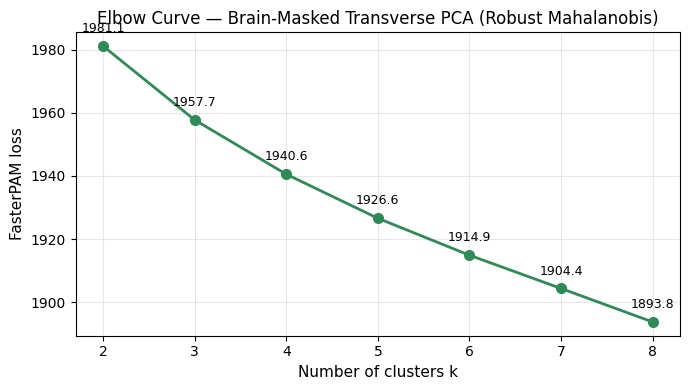

Saved: elbow_curve_masked_tra.png


In [16]:
losses_mtr = {}
print("k    loss")
print("-" * 20)
for k in range(2, 9):
    res = kmedoids.fasterpam(D_mtr, medoids=k, random_state=42)
    losses_mtr[k] = res.loss
    print(f"{k}    {res.loss:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(losses_mtr.keys()), list(losses_mtr.values()),
        marker="o", linewidth=2, markersize=7, color="seagreen")
for k, loss in losses_mtr.items():
    ax.annotate(f"{loss:.1f}", xy=(k, loss),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=9)
ax.set_xlabel("Number of clusters k", fontsize=11)
ax.set_ylabel("FasterPAM loss", fontsize=11)
ax.set_title("Elbow Curve — Brain-Masked Transverse PCA (Robust Mahalanobis)", fontsize=12)
ax.set_xticks(range(2, 9))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(NB_DIR, "elbow_curve_masked_tra.png"), dpi=150)
plt.show()
print("Saved: elbow_curve_masked_tra.png")

### Step 4 — K-Medoids FasterPAM: k=3 and k=4

Running both k values so we can directly compare CDR alignment at each.

In [17]:
def show_crosstab(labels, ids, label):
    res_df = pd.DataFrame({"patient_id": ids, "cluster": labels})
    res_df = res_df.merge(cdr, on="patient_id", how="left")
    has = res_df[res_df["CDR"].notnull()].copy()
    has["CDR"] = has["CDR"].astype(str)

    print(f"── {label} ──")
    print("Cluster sizes:")
    print(res_df["cluster"].value_counts().sort_index().rename("count").to_string())
    print()
    ct = pd.crosstab(has["cluster"], has["CDR"], margins=True, margins_name="Total")
    print("Cluster × CDR (counts):")
    display(ct)
    ct_norm = pd.crosstab(has["cluster"], has["CDR"], normalize="index").round(3)
    print("Row-normalised:")
    display(ct_norm)
    print()

# k=3
res_mtr3 = kmedoids.fasterpam(D_mtr, medoids=3, random_state=42)
show_crosstab(np.array(res_mtr3.labels), mtr_ids, "Masked Transverse — k=3")

── Masked Transverse — k=3 ──
Cluster sizes:
cluster
0     85
1    231
2    100

Cluster × CDR (counts):


CDR,0.0,0.5,1.0,2.0,Total
cluster,,,,,
0,29,37,18,1,85
1,60,16,1,1,78
2,46,17,9,0,72
Total,135,70,28,2,235


Row-normalised:


CDR,0.0,0.5,1.0,2.0
cluster,,,,
0,0.341,0.435,0.212,0.012
1,0.769,0.205,0.013,0.013
2,0.639,0.236,0.125,0.000


In [18]:
# k=4
res_mtr4 = kmedoids.fasterpam(D_mtr, medoids=4, random_state=42)
show_crosstab(np.array(res_mtr4.labels), mtr_ids, "Masked Transverse — k=4")

── Masked Transverse — k=4 ──
Cluster sizes:
cluster
0     85
1    182
2     93
3     56

Cluster × CDR (counts):


CDR,0.0,0.5,1.0,2.0,Total
cluster,,,,,
0,29,37,18,1,85
1,49,15,1,1,66
2,44,15,9,0,68
3,13,3,0,0,16
Total,135,70,28,2,235


Row-normalised:


CDR,0.0,0.5,1.0,2.0
cluster,,,,
0,0.341,0.435,0.212,0.012
1,0.742,0.227,0.015,0.015
2,0.647,0.221,0.132,0.000
3,0.812,0.188,0.000,0.000
